<a href="https://colab.research.google.com/github/Subhranshu-123/BIKE2/blob/main/AIRLINE_DEMAND_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 The Business Problem: Capacity vs. Perishable Inventory

    The Problem: Airline seats are "perishable" inventory—if a flight departs from Delhi to Mumbai with 20 empty seats, that revenue is lost forever.
    The Conflict: IndiGo relies on ultra-high aircraft utilization (often >99% efficiency) to stay profitable as a low-cost carrier. However, this leaves zero "buffer" or "slack" in the system.
    The Risk: Under-forecasting demand leads to lost revenue, while over-forecasting leads to high operational costs and empty seats.
    Recent Context: In late 2025, IndiGo faced a massive crisis where scheduling failures led to over 1,000 cancellations, impacting 1.8 lakh passengers because their capacity planning did not account for operational volatilit

. Install Required Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn

Create / Load Airline Demand Dataset

### Dataset Creation for Airline Passenger Demand

In this step, we generate a **synthetic time-series dataset** representing daily airline passenger demand for two years (730 days). This dataset includes three important components commonly found in real airline demand data:

1. **Trend Component**  
   - Represents the long-term increase in passenger demand over time.
   - Created using a linear function from **100 to 200 passengers** across 730 days.

2. **Seasonal Component**  
   - Represents repeating yearly patterns such as holidays, tourism seasons, and festivals.
   - Modeled using a **sinusoidal function** to simulate yearly seasonality.

3. **Noise Component**  
   - Random fluctuations caused by unpredictable factors such as weather, economic changes, or operational disruptions.
   - Generated using a **normal distribution**.

The final passenger demand is calculated as:

\[
Passenger\ Demand = Trend + Seasonality + Noise
\]

### Code Explanation

- `np.random.seed(42)` ensures reproducibility of random numbers.
- `pd.date_range()` creates a sequence of **daily dates** starting from **January 1, 2022**.
- `np.linspace()` generates a smooth increasing **trend**.
- `np.sin()` creates a **seasonal pattern** repeating every 365 days.
- `np.random.normal()` introduces random **noise**.
- A **Pandas DataFrame** is created to store the dataset.
- The **date column is set as the index** to convert the dataset into a proper **time series format**.

### Result

The resulting dataset contains:

| Date | Passengers |
|-----|-----|
| 2022-01-01 | 102.48 |
| 2022-01-02 | 100.98 |
| 2022-01-03 | 105.12 |
| 2022-01-04 | 110.76 |
| 2022-01-05 | 103.45 |



In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

dates = pd.date_range(start="2022-01-01", periods=730, freq='D')

trend = np.linspace(100,200,730)
seasonal = 20*np.sin(np.arange(730)*2*np.pi/365)
noise = np.random.normal(0,5,730)

passengers = trend + seasonal + noise

df = pd.DataFrame({
    "date":dates,
    "passengers":passengers
})

df.set_index("date", inplace=True)

df.head()

,passengers
date,
2022-01-01,102.483571
2022-01-02,99.790120
2022-01-03,104.201223
2022-01-04,109.059065
2022-01-05,100.753979


In [18]:
print(df)

            passengers  trend  detrended  seasonal  deseasonalized      diff
date                                                                        
2022-01-01  102.483571    NaN        NaN -1.839016      104.322587       NaN
2022-01-02   99.790120    NaN        NaN  1.633341       98.156779 -2.693451
2022-01-03  104.201223    NaN        NaN  0.925218      103.276005  4.411104
2022-01-04  109.059065    NaN        NaN  1.703192      107.355873  4.857842
2022-01-05  100.753979    NaN        NaN -2.297967      103.051945 -8.305087
...                ...    ...        ...       ...             ...       ...
2023-12-27  196.812090    NaN        NaN  1.008823      195.803267 -1.294332
2023-12-28  198.304598    NaN        NaN  6.395660      191.908939  1.492508
2023-12-29  200.431167    NaN        NaN -1.397060      201.828227  2.126568
2023-12-30  196.475595    NaN        NaN  1.518748      194.956847 -3.955572
2023-12-31  195.764209    NaN        NaN  3.285427      192.478782 -0.711386

Time Series Visualization
This shows trend + seasonality.

### Time Series Visualization of Airline Passenger Demand

In this step, we visualize the **airline passenger demand time series** using a line plot.  
Visualization is important in time-series analysis because it helps identify key patterns such as:

- **Trend** – long-term increase or decrease in passenger demand.
- **Seasonality** – repeating patterns over time (e.g., holidays, tourism seasons).
- **Noise** – random fluctuations caused by unpredictable factors.

### Code Explanation

- `plt.figure(figsize=(12,6))`  
  Creates a larger figure for better visualization.

- `plt.plot(df['passengers'])`  
  Plots the passenger demand values over time.

- `plt.title("Airline Passenger Demand")`  
  Adds a title to the chart to describe the visualization.

- `plt.show()`  
  Displays the plot.

### Purpose of the Plot

This visualization helps us:

1. Understand overall demand behavior.
2. Detect seasonal fluctuations in airline bookings.
3. Identify long-term growth trends in passenger traffic.
4. Prepare the dataset for further **time-series analysis techniques** such as:
   - Decomposition
   - Detrending
   - Deseasonalization
   - ACF & PACF analysis
   

### Expected Output

A **line chart** showing daily passenger demand over time.  
The graph typically displays:

- An **upward trend** indicating growing demand.
- **Seasonal oscillations** caused by yearly travel patterns.
- **Random noise** representing real-world variability.

### Airline Passenger Demand Time Series

The following plot shows the **daily airline passenger demand** over time.  
This visualization helps us understand the **trend, seasonal patterns, and variability** in passenger demand.

### Key Observations from the Plot

1. **Upward Trend**

The passenger demand gradually increases from **2022 to 2024**, indicating a **long-term growth trend** in airline travel demand.

2. **Seasonal Pattern**

There are visible **periodic fluctuations** in the demand. These variations may correspond to:

- Holiday travel seasons
- Festival periods
- Tourism demand cycles

3. **Random Noise**

Small irregular fluctuations appear throughout the series. These variations may occur due to:

- Weather conditions
- Operational disruptions
- Sudden travel demand changes

### Interpretation

| Component | Observation |
|-----------|-------------|
| Trend | Increasing passenger demand over time |
| Seasonality | Periodic rises and falls in demand |
| Noise | Random fluctuations |

### Importance for Airline Forecasting

Understanding the demand pattern helps airlines:

- Forecast **future passenger demand**
- Optimize **seat capacity planning**
- Improve **dynamic ticket pricing**
- Reduce **empty seat losses**

### Role in Time Series Modeling

This time-series plot is the **first step** in the forecasting workflow:

1. Visualize demand patterns
2. Perform **decomposition (trend + seasonality)**
3. Apply **stationarity tests**
4. Build forecasting models like **ARIMA**
5. Predict **future passenger demand**

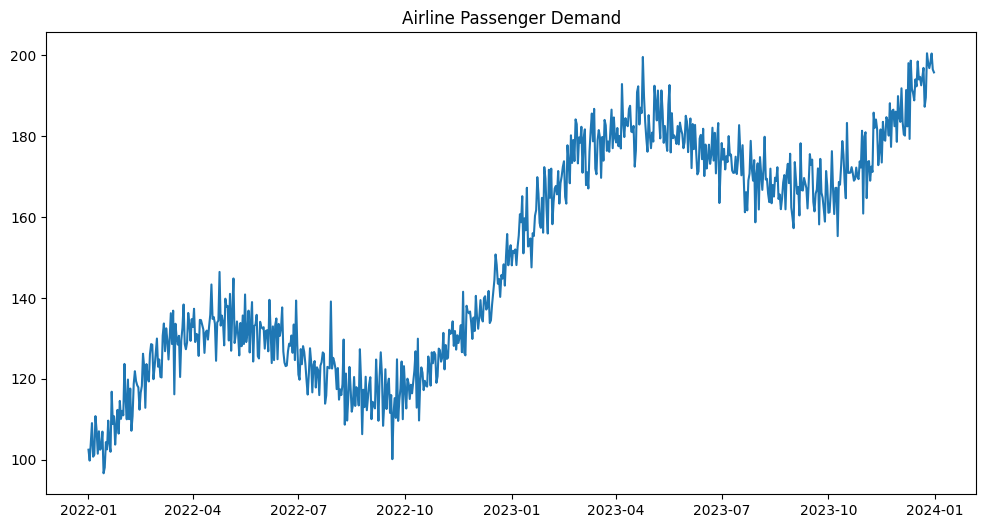

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['passengers'])
plt.title("Airline Passenger Demand")
plt.show()

Decomposition of Time Series
Additive Model
Y=Trend+Seasonality+Noise
Y=Trend+Seasonality+Noise

### Additive Time Series Decomposition

In this step, we perform **seasonal decomposition** of the airline passenger demand time series using an **additive model**. Decomposition helps break the time series into its fundamental components for better understanding and forecasting.

Y = T + S + E

Where:

- **Y** = Observed time series (Passenger demand)  
- **T** = Trend component (long-term growth or decline)  
- **S** = Seasonal component (repeating patterns over time)  
- **E** = Residual / Random noise  

### Code Explanation

- `seasonal_decompose()`  
  Decomposes the time series into **trend, seasonal, and residual components**.

- `df['passengers']`  
  The time-series data representing daily airline passenger demand.

- `model='additive'`  
  Assumes that the components combine through **addition**.

- `period=365`  
  Specifies the seasonal cycle length.  
  Since airline demand typically follows **yearly patterns**, a period of **365 days** is used.

- `decompose_add.plot()`  
  Plots the decomposition results.

- `plt.show()`  
  Displays the decomposition graphs.

### Output Components

The decomposition produces four plots:

1. **Observed Series**  
   Original passenger demand data.

2. **Trend Component**  
   Long-term increase or decrease in airline demand.

3. **Seasonal Component**  
   Regular yearly patterns caused by tourism seasons, holidays, and festivals.

4. **Residual Component**  
   Random fluctuations not explained by trend or seasonality.

### Why Decomposition is Important

For airline revenue management systems (similar to those used by airlines like IndiGo):

- Helps identify **demand trends**
- Detects **seasonal travel patterns**
- Improves **forecasting accuracy**
- Supports **capacity planning and pricing strategies**

### Interpretation

If the seasonal pattern remains **constant in magnitude over time**, the **additive model** is appropriate. If seasonal variation increases with demand, a **multiplicative model** should be used instead.

Decomposition Analysis

    Original Data (passengers): Shows a clear upward trajectory combined with a strong repeating cyclical pattern.
    Trend: This confirms a steady upward growth over time. The trend line is roughly linear, indicating consistent long-term increases in passenger numbers.
    Seasonal: There is a distinct periodic cycle. Numbers peak around April (04) and October (10) and dip significantly in July (07) and January (01). This suggests a semi-annual seasonal effect.
    Resid (Residuals): Most of the noise is centered at zero, meaning the trend and seasonality explain the data very well. However, there are two significant outliers around July 2022 and July 2023 that the model didn't capture.

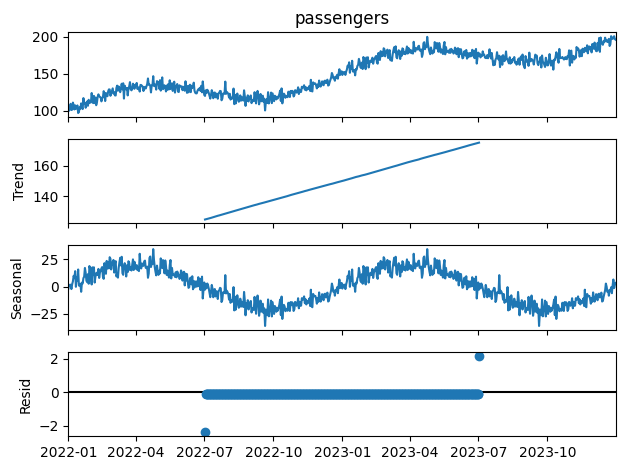

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose_add = seasonal_decompose(df['passengers'], model='additive', period=365)

decompose_add.plot()
plt.show()

Multiplicative Model
Y=Trend×Seasonality×Noise
Y=Trend×Seasonality×Noise

### Multiplicative Time Series Decomposition

In this step, we decompose the airline passenger demand time series using a **multiplicative model**. This model is used when the **seasonal variations change proportionally with the level of the time series**.

Y = T × S × E

Where:

- **Y** = Observed time series (Passenger demand)  
- **T** = Trend component (long-term increase or decrease)  
- **S** = Seasonal component (periodic fluctuations)  
- **E** = Residual / Irregular component  

### Code Explanation

- `seasonal_decompose()`  
  This function decomposes the time series into **trend, seasonal, and residual components**.

- `df['passengers']`  
  The passenger demand time-series data.

- `model='multiplicative'`  
  Assumes the components combine through **multiplication** rather than addition.

- `period=365`  
  Indicates a **yearly seasonal cycle** (365 days), which is common in airline demand due to tourism seasons, holidays, and festivals.

- `decompose_mul.plot()`  
  Generates plots for each component of the decomposition.

- `plt.show()`  
  Displays the plots.

### Output Components

The decomposition produces four visual components:

1. **Observed Series**  
   The original airline passenger demand data.

2. **Trend Component**  
   Long-term movement in passenger demand.

3. **Seasonal Component**  
   Repeating yearly travel patterns (holiday peaks, off-season dips).

4. **Residual Component**  
   Random variations not explained by trend or seasonality.

### When to Use Multiplicative Model

The multiplicative model is preferred when:

- Seasonal fluctuations **increase as demand increases**
- Variability is **proportional to the level of the series**
- High-demand periods show **larger seasonal peaks**

### Importance for Airline Revenue Management

Understanding multiplicative seasonality helps airlines:

- Forecast **future passenger demand**
- Adjust **ticket pricing dynamically**
- Optimize **seat capacity allocation**
- Improve **revenue management strategies**

Decomposition Analysis

    Original Data (passengers): Shows a clear upward trajectory combined with a strong repeating cyclical pattern and some high-frequency noise.
    Trend: This confirms a steady upward growth over time. The trend line is linear, indicating a consistent long-term increase in passenger numbers during the observed period.
    Seasonal: There is a distinct periodic cycle. The data shows peaks roughly every six months (around April and the end of the year) with significant dips in between (around July and January).
    Resid (Residuals): Interestingly, the residuals are tightly clustered around a value of 1.0 rather than 0. This suggests a multiplicative decomposition model was used (DATA=TREND*SESONAL*RESID
    ). The lack of variance here implies the trend and seasonality explain almost all of the data's movement.

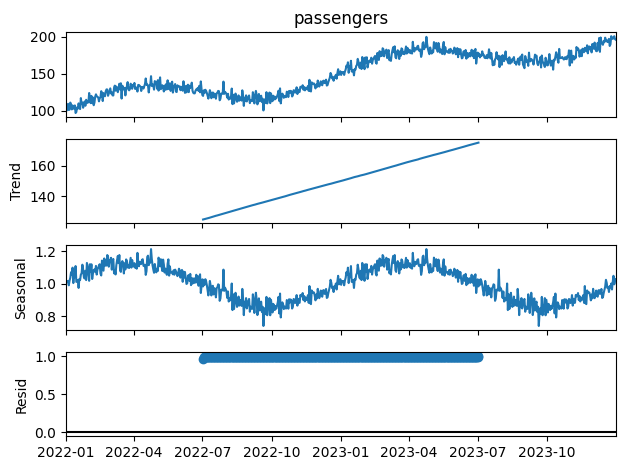

In [5]:
decompose_mul = seasonal_decompose(df['passengers'], model='multiplicative', period=365)

decompose_mul.plot()
plt.show()

Detrending

Remove the trend from the series.

### Detrending the Time Series

In this step, we remove the **trend component** from the airline passenger demand time series. Removing the trend helps us analyze the underlying seasonal and random patterns more clearly.

Detrended = Y - T

Where:

- **Y** = Original time series (Passenger demand)
- **T** = Trend component extracted from decomposition
- **Detrended** = Time series after removing the trend

### Code Explanation

- `df['trend'] = decompose_add.trend`  
  Extracts the **trend component** obtained from the additive decomposition and stores it in the dataset.

- `df['detrended'] = df['passengers'] - df['trend']`  
  Removes the trend from the passenger demand series.

- `plt.figure(figsize=(12,6))`  
  Creates a larger figure for better visualization.

- `plt.plot(df['detrended'])`  
  Plots the detrended time series.

- `plt.title("Detrended Series")`  
  Adds a title to the visualization.

- `plt.show()`  
  Displays the plot.

### Purpose of Detrending

Detrending is important in time-series analysis because:

- It removes long-term growth patterns.
- It allows better identification of **seasonal patterns**.
- It helps prepare the data for **stationarity tests**.
*.

### Expected Output

The resulting graph will show a **fluctuating series centered around zero**, where the long-term upward trend has been removed. This allows us to focus on **seasonal variations and random noise** in airline passenger demand.

Seasonality: A strong annual cyclical pattern is visible. The series dips to its lowest point around September/October 2022 and peaks around March/April 2023. This suggests that while the overall trend is removed, there is a powerful seasonal driver (like weather or school cycles) affecting the data.
Stationarity: By removing the trend, the series now oscillates around a mean of zero. This is a crucial step for making the data stationary, which is often required for advanced forecasting models like ARIMA.
Volatility (Noise): The "width" of the spikes (the noise) appears relatively consistent throughout the year, though there is a slight increase in volatility during the peak months (Spring 2023).
Significant Outliers: There is a sharp, negative spike in late September 2022 and a notable positive spike in late April 2023 that deviate significantly from the local average.

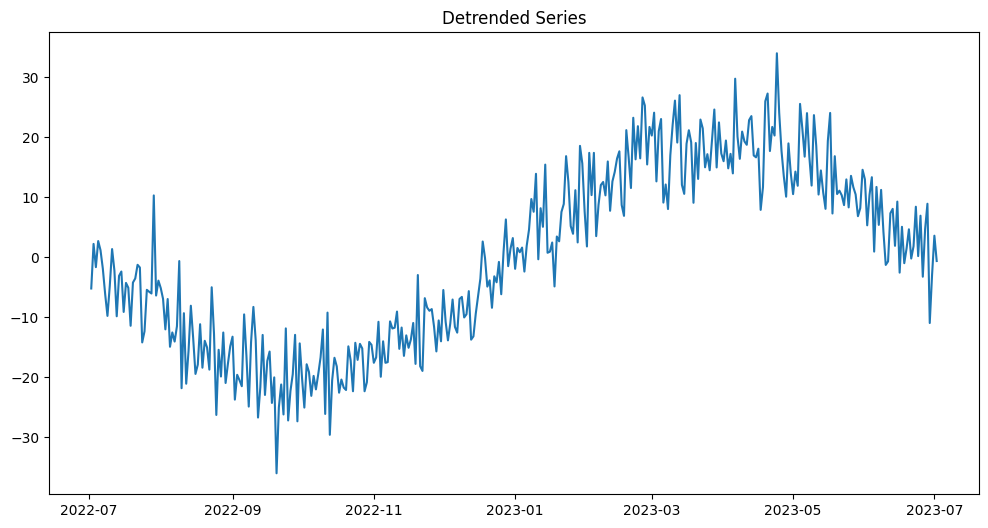

In [6]:
df['trend'] = decompose_add.trend

df['detrended'] = df['passengers'] - df['trend']

plt.figure(figsize=(12,6))
plt.plot(df['detrended'])
plt.title("Detrended Series")
plt.show()

Deseasonalization

Remove seasonal component.

### Deseasonalizing the Time Series

In this step, we remove the **seasonal component** from the airline passenger demand time series. This process is called **deseasonalization** and helps isolate the **trend and irregular components** of the data.

Deseasonalized = Y - S

Where:

- **Y** = Original time series (Passenger demand)  
- **S** = Seasonal component obtained from decomposition  
- **Deseasonalized** = Time series after removing seasonal patterns  

### Code Explanation

- `df['seasonal'] = decompose_add.seasonal`  
  Extracts the **seasonal component** from the additive decomposition.

- `df['deseasonalized'] = df['passengers'] - df['seasonal']`  
  Removes the seasonal pattern from the passenger demand data.

- `plt.figure(figsize=(12,6))`  
  Creates a larger figure for clearer visualization.

- `plt.plot(df['deseasonalized'])`  
  Plots the deseasonalized time series.

- `plt.title("Deseasonalized Series")`  
  Adds a descriptive title to the graph.

- `plt.show()`  
  Displays the resulting plot.

### Purpose of Deseasonalization

Deseasonalization is important because it:

- Removes recurring seasonal patterns.
- Allows better analysis of **long-term trends**.
.
- Makes it easier to detect **structural changes or anomalies** in airline demand.

### Expected Output

The resulting plot shows a **smoothed time series** where seasonal fluctuations have been removed.  
The series primarily reflects the **underlying trend and random variations** in airline passenger demand.

Analysis of Deseasonalized Series

    Underlying Trend: The plot reveals a very clear, strong upward trend. With the seasonal "noise" gone, it is evident that the values have nearly doubled—moving from around 100 in early 2022 to approximately 200 by early 2024.
    The Data Gap: There is a significant missing data period between July 2022 and July 2023. The straight diagonal line connecting these two points is an interpolation (a "best guess" bridge) rather than actual recorded data.
    Volatility Profile:
        2022 Segment: Shows moderate volatility with a notable downward spike in early 2022 and an upward spike just before July.
        2023/2024 Segment: The data appears more "jagged" or volatile than the 2022 section, suggesting that the underlying variance increased after the one-year gap.
    Stationarity: This series is non-stationary. Because the mean is clearly shifting upward over time, further differencing would be required before this could be used in a model like ARIMA.

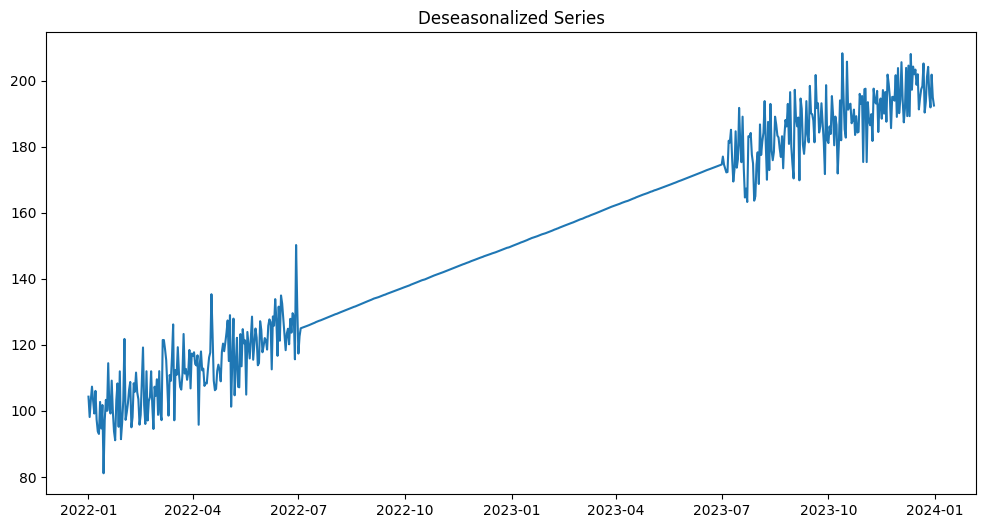

In [7]:
df['seasonal'] = decompose_add.seasonal

df['deseasonalized'] = df['passengers'] - df['seasonal']

plt.figure(figsize=(12,6))
plt.plot(df['deseasonalized'])
plt.title("Deseasonalized Series")
plt.show()

ACF (Autocorrelation Function)

Shows correlation between time lags.
Interpretation:

Gradual decay → AR model

Sharp cutoff → MA model

### Autocorrelation Function (ACF) Plot

In this step, we analyze the **autocorrelation structure** of the airline passenger demand time series using the **ACF (Autocorrelation Function)**.

The ACF measures how strongly the current value of the time series is correlated with its **past values (lags)**.

ACF(k) = Corr(Y_t, Y_{t-k})

Where:

- **Yₜ** = Value of the time series at time *t*
- **Yₜ₋ₖ** = Value of the time series at lag *k*
- **k** = Number of lag periods
- **Corr** = Correlation between the two values

### Code Explanation

- `from statsmodels.graphics.tsaplots import plot_acf`  
  Imports the function used to generate the **ACF plot**.

- `plot_acf(df['passengers'], lags=40)`  
  Computes and plots autocorrelation values for **40 lag periods**.

- `lags=40`  
  Shows correlations between the current observation and the **previous 40 time steps**.

- `plt.show()`  
  Displays the ACF plot.

### Interpretation of the ACF Plot

The ACF plot helps identify patterns in time series data:

1. **Slow decay of correlations**
   - Indicates the presence of **trend or non-stationarity**.

2. **Sharp cutoff after a few lags**
   - Suggests a **Moving Average (MA) model**.

3. **Seasonal spikes at fixed intervals**
   - Indicates **seasonal patterns** in the data.

### Importance in Time Series Modeling

The ACF plot is widely used to:

- Identify **time dependencies**
- Detect **seasonality**
- Determine the **order of MA(q)** in ARIMA models
- Check whether the time series is **stationary**

### Expected Output

The resulting plot will show:

- **Lag values on the x-axis**
- **Autocorrelation values on the y-axis**
- Confidence intervals indicating whether correlations are statistically significant.

ACF Interpretation

    Non-Stationarity: The most critical observation is that the ACF decays very slowly and stays well above the blue significance zone for all 40 lags. This is a classic indicator that the data is non-stationary and likely contains a strong trend.
    High Persistence: The high correlation at early lags (near 1.0) shows that each value is heavily dependent on its recent past. If today’s value is high, tomorrow’s is extremely likely to be high as well.
    Linear Decay: The almost linear downward slope suggests a consistent, deterministic trend rather than a rapidly changing or purely seasonal one.
    Significance: Because the stems remain outside the light blue shaded region (the 95% confidence interval), the correlations at all 40 lags are statistically significant.

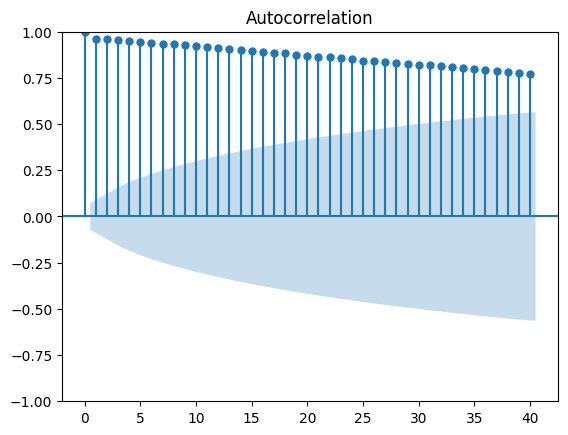

In [8]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['passengers'], lags=40)
plt.show()

PACF (Partial Autocorrelation)

Helps identify AR order

### Partial Autocorrelation Function (PACF) Plot

In this step, we analyze the **Partial Autocorrelation Function (PACF)** of the airline passenger demand time series. The PACF measures the correlation between the current value and its lagged values **after removing the effects of intermediate lags**.

PACF(k) = Corr(Y_t, Y_{t-k} | Y_{t-1},...,Y_{t-k+1})

Where:

- **Yₜ** = Value of the time series at time *t*  
- **Yₜ₋ₖ** = Value of the time series at lag *k*  
- **k** = Number of lag periods  
- The correlation is calculated **after controlling for all shorter lags**.

### Code Explanation

- `from statsmodels.graphics.tsaplots import plot_pacf`  
  Imports the function used to generate the **PACF plot**.

- `plot_pacf(df['passengers'], lags=40)`  
  Computes and plots partial autocorrelations for **40 lag periods**.

- `lags=40`  
  Displays correlations between the current observation and the **previous 40 lagged observations**, controlling for intermediate lags.

- `plt.show()`  
  Displays the PACF plot.

### Interpretation of the PACF Plot

The PACF plot helps identify the **autoregressive (AR) order** in time-series models:

1. **Sharp cutoff after lag p**
   - Indicates an **AR(p) model**.

2. **Gradual decline**
   - Suggests the presence of **MA components**.

3. **Seasonal spikes**
   - Indicate **seasonal autoregressive patterns**.

### Importance in Time-Series Modeling

PACF is widely used for:

- Determining the **AR(p)** order in **ARIMA models**
- Understanding direct relationships between observations and their lags
- Identifying structure in time-series data

### Expected Output

The PACF plot will show:

- **Lag values on the x-axis**
- **Partial autocorrelation values on the y-axis**
- Confidence intervals indicating whether lag correlations are statistically significant.

PACF Interpretation

    Significant Lags: There are two primary spikes that clearly cross the blue significance threshold (at Lag 1 and Lag 2).
        Lag 1 is extremely high (near 1.0), which is typical for data with a strong trend.
        Lag 2 is significantly lower (around 0.45) but still very much statistically significant.
    The "Cut-Off" Point: After Lag 2, the correlations drop off sharply. While there are minor blips at Lag 3 and Lag 5, the most dominant relationship is captured within the first two steps.
    Stationarity Reminder: Like the previous ACF plot, the massive spike at Lag 1 confirms the data is likely non-stationary. The PACF is showing you the correlation after controlling for the intermediate lags.

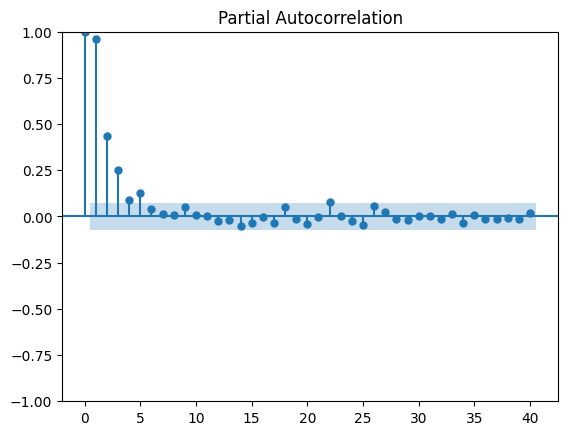

In [9]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df['passengers'], lags=40)
plt.show()

Stationarity Check (ADF Test)

### Augmented Dickey-Fuller (ADF) Test for Stationarity

In this step, we perform the **Augmented Dickey-Fuller (ADF) test** to determine whether the airline passenger demand time series is **stationary or non-stationary**.

A **stationary time series** has:
- Constant mean
- Constant variance
- No trend over time

Most time-series forecasting models like **ARIMA** require the data to be **stationary**.

H0: series has a unit root (non-stationary) ; H1: series is stationary

### Code Explanation

- `from statsmodels.tsa.stattools import adfuller`  
  Imports the **ADF test function** from the statsmodels library.

- `result = adfuller(df['passengers'])`  
  Performs the ADF test on the passenger demand time series.

- `result[0]`  
  Returns the **ADF test statistic**.

- `result[1]`  
  Returns the **p-value** of the test.

- `print()`  
  Displays the ADF statistic and p-value.

### Interpretation of Results

| p-value | Conclusion |
|-------|-------------|
| p-value ≤ 0.05 | Reject H₀ → Series is **stationary** |
| p-value > 0.05 | Fail to reject H₀ → Series is **non-stationary** |

### Why Stationarity Matters

Stationarity is important because:

- It ensures **stable statistical properties**
- It improves **forecasting accuracy**
- It allows models like **ARIMA, SARIMA, and AR models** to work correctly

### What to Do If the Series is Non-Stationary

If the p-value is greater than **0.05**, the time series is non-stationary.  
To fix this, we can apply techniques such as:

- **Differencing**
- **Log transformation**
- **Detrending**
- **Deseasonalization**

These methods help convert the series into a **stationary time series suitable for forecasting models**.

In [10]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['passengers'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.6596068805259339
p-value: 0.8569367434698906


Differencing (Make Series Stationary)

### Differencing the Time Series

In this step, we apply **first-order differencing** to the airline passenger demand time series. Differencing is a common technique used to **remove trend and make the time series stationary**.

Y'_t = Y_t - Y_{t-1}

Where:

- **Yₜ** = Value at current time step  
- **Yₜ₋₁** = Value at the previous time step  
- **Y'ₜ** = Differenced series  

### Code Explanation

- `df['diff'] = df['passengers'].diff()`  
  Computes the **first difference** of the passenger demand series by subtracting each value from its previous value.

- `.diff()`  
  Automatically calculates the difference between consecutive observations.

- `df['diff'].dropna()`  
  Removes the first missing value created by differencing.

- `.plot(figsize=(12,6))`  
  Plots the differenced time series.

- `plt.title("Differenced Series")`  
  Adds a title to the visualization.

- `plt.show()`  
  Displays the plot.

### Purpose of Differencing

Differencing is used to:

- Remove **trend** from the data
- Achieve **stationarity**
- Stabilize the mean of the time series
- Prepare the data for **ARIMA modeling**

### Expected Output

The resulting plot should show a **series fluctuating around zero**, indicating that the trend has been removed. This transformed series is more suitable for **time-series forecasting models such as ARIMA or SARIMA**.

Stationarity Achieved: This is the most important result. The strong upward trend and seasonal "wave" from previous steps have been neutralized. The series now oscillates around a constant mean of zero, which is a requirement for many time-series models.
Volatility and Shocks: While the trend is gone, the "noise" or volatility remains. You can see several significant shocks (spikes reaching
to
). These represent sudden, sharp changes in passenger numbers from one period to the next that weren't part of the general trend.
Data Continuity: Unlike the "Deseasonalized" plot which showed a flat diagonal line during the 2022–2023 gap, this plot shows continuous activity. This suggests the differencing was likely performed on the interpolated (estimated) data.
Clustering: There is some evidence of "volatility clustering"—periods where the spikes are consistently larger (e.g., late 2023) followed by periods of relative calm.

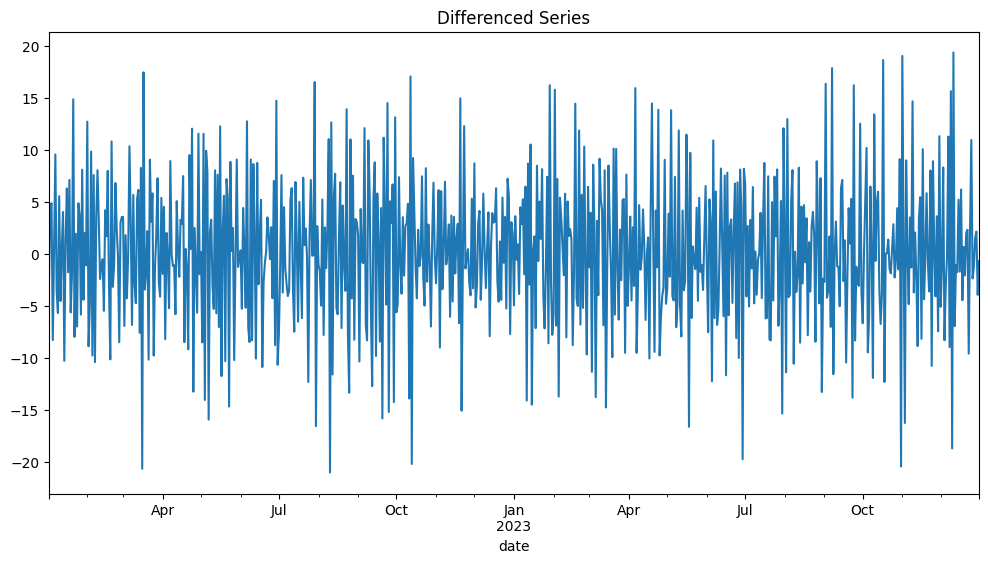

In [11]:
df['diff'] = df['passengers'].diff()

df['diff'].dropna().plot(figsize=(12,6))
plt.title("Differenced Series")
plt.show()

Train/Test Split

### Train–Test Split for Time Series Forecasting

In this step, we divide the dataset into **training data** and **testing data**. This is necessary to evaluate how well our forecasting model performs on **unseen future data**.

Unlike traditional machine learning, **time series data must be split sequentially**, preserving the chronological order.

### Code Explanation

- `train = df[:600]`  
  Selects the **first 600 observations** of the dataset as the **training set**.

- `test = df[600:]`  
  Selects the **remaining observations** as the **testing set**.

### Why Sequential Splitting is Important

In time series forecasting:

- We **train the model using past data**
- We **predict future values**
- Random shuffling is **not allowed** because it would break the time dependency.

### Dataset Split Structure

| Dataset | Observations | Purpose |
|-------|--------------|--------|
| Training Set | First 600 records | Used to train the forecasting model |
| Testing Set | Remaining records | Used to evaluate prediction accuracy |

### Example Workflow

1. Train the model using the **training dataset**.
2. Generate forecasts for the **testing period**.
3. Compare predicted values with actual values using metrics such as:
   - **MAE (Mean Absolute Error)**
   - **RMSE (Root Mean Square Error)**
   - **MAPE (Mean Absolute Percentage Error)**

### Purpose in Airline Demand Forecasting

Splitting the dataset helps simulate a real-world scenario where airlines:

- Use **historical passenger data** to train forecasting models.
- Predict **future travel demand**.
- Optimize **seat capacity, pricing, and scheduling decisions**.

In [12]:
train = df[:600]
test = df[600:]

ARIMA Model for Forecasting

### ARIMA Model for Airline Passenger Demand Forecasting

In this step, we build an **ARIMA (AutoRegressive Integrated Moving Average)** model to forecast airline passenger demand using historical data.

ARIMA is one of the most widely used models for **time series forecasting**, especially when the data shows **trend and autocorrelation**.

ARIMA(p, d, q)

Where:

- **p** → Number of **Autoregressive (AR) terms**  
- **d** → Number of **Differencing operations** used to make the series stationary  
- **q** → Number of **Moving Average (MA) terms**

For this model:

- **p = 2**
- **d = 1**
- **q = 2**

So the model used is **ARIMA(2,1,2)**.

### Code Explanation

- `from statsmodels.tsa.arima.model import ARIMA`  
  Imports the ARIMA model from the **statsmodels library**.

- `model = ARIMA(train['passengers'], order=(2,1,2))`  
  Defines the ARIMA model using the training dataset.

- `order=(2,1,2)`  
  Specifies the ARIMA parameters:
  - **2 AR terms**
  - **1 differencing**
  - **2 MA terms**

- `model_fit = model.fit()`  
  Trains (fits) the ARIMA model on the training data.

- `print(model_fit.summary())`  
  Displays the **statistical summary** of the model including:
  - AR coefficients
  - MA coefficients
  - AIC and BIC values
  - Standard errors
  - Diagnostic statistics

### Model Output Interpretation

The summary table typically includes:

| Parameter | Meaning |
|-----------|---------|
| **coef** | Estimated coefficient values |
| **std err** | Standard error of coefficients |
| **z-value** | Statistical significance |
| **P>|z|** | p-value for hypothesis testing |
| **AIC / BIC** | Model selection criteria |

Lower **AIC or BIC values** usually indicate a **better model fit**.

### Importance in Airline Revenue Management

Using ARIMA forecasting allows airlines to:

- Predict **future passenger demand**
- Optimize **seat allocation**
- Adjust **ticket pricing dynamically**
- Improve **capacity planning**

### ARIMA(2,1,2) Model Results Interpretation

The ARIMA model was trained on the airline passenger demand dataset to forecast future demand.  
The model used is:

ARIMA(2,1,2)

Where:

- **p = 2** → two autoregressive terms  
- **d = 1** → first-order differencing to achieve stationarity  
- **q = 2** → two moving average terms  

### Model Information

| Metric | Value |
|------|------|
| Observations | 600 |
| Log Likelihood | -1847.111 |
| AIC | 3704.222 |
| BIC | 3726.198 |

Lower **AIC and BIC values** generally indicate a better model fit.

### Coefficient Interpretation

| Parameter | Coefficient | p-value | Interpretation |
|----------|-------------|---------|---------------|
| AR(1) | -0.8687 | 0.000 | Highly significant lag effect |
| AR(2) | -0.1027 | 0.048 | Slightly significant |
| MA(1) | 0.0351 | 0.854 | Not statistically significant |
| MA(2) | -0.6157 | 0.000 | Strong moving average effect |

Key Insight:
- **AR terms are important in explaining passenger demand patterns.**
- **MA(1) is not significant**, meaning it contributes little to the model.

### Variance of Residuals

| Parameter | Value |
|----------|------|
| sigma² | 27.87 |

This represents the **variance of the model residuals**.

### Diagnostic Tests

#### 1. Ljung-Box Test
- **p-value = 0.81**
- Indicates **no significant autocorrelation in residuals**
- Good sign → model captures time dependence well.

#### 2. Jarque-Bera Test
- **p-value = 0.86**
- Residuals are **normally distributed**.

#### 3. Heteroskedasticity Test
- **p-value = 0.44**
- Residuals show **constant variance**.

### Model Conclusion

The ARIMA(2,1,2) model performs reasonably well because:

- Residuals show **no autocorrelation**
- Errors are **normally distributed**
- Variance is **stable**

Therefore, this model can be used for **forecasting airline passenger demand**.

### Warning Message Explanation

The warning:


In [13]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['passengers'], order=(2,1,2))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             passengers   No. Observations:                  600
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1847.111
Date:                Tue, 10 Mar 2026   AIC                           3704.222
Time:                        05:23:29   BIC                           3726.198
Sample:                    01-01-2022   HQIC                          3712.777
                         - 08-23-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8687      0.196     -4.425      0.000      -1.254      -0.484
ar.L2         -0.1027      0.052     -1.981      0.048      -0.204      -0.001
ma.L1          0.0351      0.190      0.184      0.8

Forecast Future Demand

### Forecasting Future Passenger Demand using ARIMA

In this step, we generate forecasts using the trained **ARIMA(2,1,2)** model and compare the predicted values with the actual test dataset.

Forecasting helps evaluate how well the model predicts **future airline passenger demand**.

### Code Explanation

- `forecast = model_fit.forecast(steps=len(test))`  
  Generates forecasts for the same number of observations as the **test dataset**.

- `steps=len(test)`  
  Ensures the forecast length matches the number of test samples.

- `plt.figure(figsize=(12,6))`  
  Creates a large figure for better visualization.

- `plt.plot(train['passengers'], label="Train")`  
  Plots the **training data** used to build the model.

- `plt.plot(test['passengers'], label="Test")`  
  Plots the **actual passenger demand** in the testing dataset.

- `plt.plot(test.index, forecast, label="Forecast")`  
  Plots the **predicted values** generated by the ARIMA model.

- `plt.legend()`  
  Adds labels to differentiate train, test, and forecast data.

- `plt.show()`  
  Displays the final visualization.

### Purpose of the Forecast Plot

This plot helps us visually evaluate:

1. **Model accuracy**
2. **How closely predictions follow actual demand**
3. **Future demand patterns**

### Expected Output

The graph will contain three lines:

| Line | Description |
|-----|-------------|
| Train | Historical data used to train the model |
| Test | Actual passenger demand values |
| Forecast | Predicted values from the ARIMA model |

A good forecasting model will show the **forecast line closely following the test data trend**.

### Importance for Airline Revenue Management

Accurate passenger demand forecasting allows airlines to:

- Optimize **seat capacity planning**
- Reduce **empty seats and revenue loss**
- Improve **dynamic ticket pricing strategies**
- Better manage **flight schedules and fleet utilization**

Model Performance Analysis

    The Forecast (Green Line): The model has produced a "flat" or "mean-reverting" forecast. It effectively predicts a constant value of approximately 165 for the entire test period.
    The Test Data (Orange Line): In reality, the actual data continued to show high volatility and a significant resumed upward trend, ending near 200 by January 2024.
    Discrepancy: The model failed to capture two critical elements:
        Trend Persistence: It assumed the slight dip at the end of the training set (blue) would stabilize, rather than continuing the long-term growth.
        Seasonality: The forecast did not account for the cyclical "wave" patterns identified in your earlier decomposition steps.

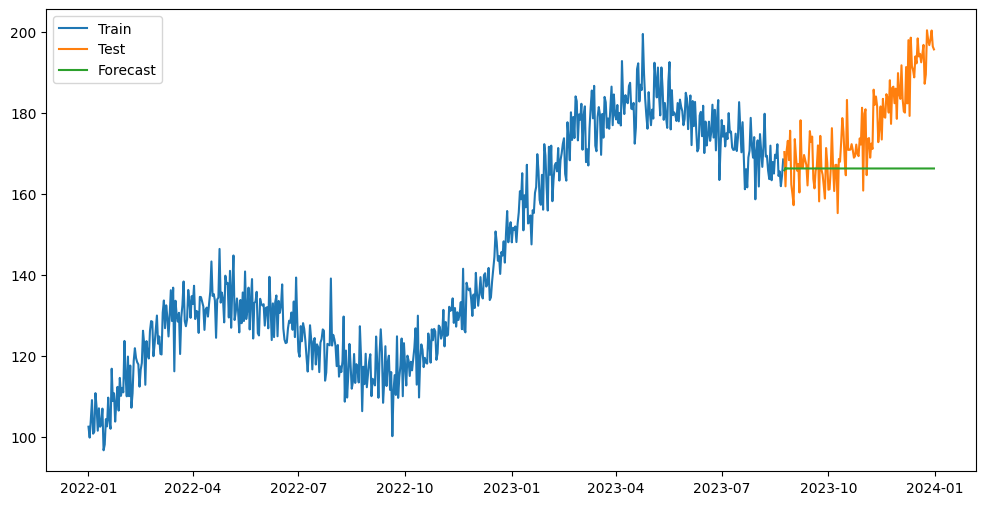

In [14]:
forecast = model_fit.forecast(steps=len(test))

plt.figure(figsize=(12,6))

plt.plot(train['passengers'], label="Train")
plt.plot(test['passengers'], label="Test")
plt.plot(test.index, forecast, label="Forecast")

plt.legend()
plt.show()

Model Evaluation

### Model Evaluation using MAE and RMSE

After generating forecasts, it is important to evaluate how accurate the predictions are compared to the actual values in the test dataset. Two commonly used evaluation metrics for time-series forecasting are:

- **MAE (Mean Absolute Error)**
- **RMSE (Root Mean Squared Error)**

These metrics measure the difference between **actual passenger demand** and **forecasted demand**.

### 1. Mean Absolute Error (MAE)

MAE calculates the **average absolute difference** between predicted and actual values.

MAE = (1/n) * Σ |y_i - ŷ_i|

Where:

- **yᵢ** = Actual value  
- **ŷᵢ** = Predicted value  
- **n** = Number of observations  

Lower MAE indicates **better model performance**.

### 2. Root Mean Squared Error (RMSE)

RMSE measures the **square root of the average squared differences** between predicted and actual values.

RMSE = sqrt((1/n) * Σ (y_i - ŷ_i)^2)

RMSE penalizes **large prediction errors more strongly** than MAE.

### Code Explanation

- `from sklearn.metrics import mean_absolute_error, mean_squared_error`  
  Imports evaluation metrics from **scikit-learn**.

- `mae = mean_absolute_error(test['passengers'], forecast)`  
  Calculates the **MAE** between actual test values and predicted values.

- `rmse = np.sqrt(mean_squared_error(test['passengers'], forecast))`  
  Computes the **RMSE** by taking the square root of Mean Squared Error.

- `print("MAE:", mae)`  
  Displays the Mean Absolute Error.

- `print("RMSE:", rmse)`  
  Displays the Root Mean Squared Error.

### Interpretation

| Metric | Meaning |
|------|------|
| MAE | Average prediction error |
| RMSE | Penalizes larger errors more heavily |

Smaller values of **MAE and RMSE** indicate that the **forecast model is more accurate**.

### Business Insight for Airlines

Accurate forecasting with low MAE/RMSE helps airlines to:

- Predict **future passenger demand**
- Optimize **flight capacity**
- Reduce **empty seats**
- Improve **revenue management strategies**

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['passengers'], forecast)

rmse = np.sqrt(mean_squared_error(test['passengers'], forecast))

print("MAE:",mae)
print("RMSE:",rmse)

MAE: 11.768423456330831
RMSE: 15.260393841457626


Revenue Optimization Example

### Airline Revenue Estimation using Forecasted Demand

After forecasting passenger demand using the ARIMA model, we estimate the **expected revenue for a flight**.  
This step connects **time-series forecasting with airline revenue management**.

Revenue depends on three key factors:

1. **Seat Capacity of the Aircraft**
2. **Predicted Passenger Demand**
3. **Ticket Price**

### Revenue Calculation Logic

If predicted demand exceeds the available seats, the airline can only sell up to the **maximum seat capacity**.

Revenue = min(PredictedDemand, SeatCapacity) × TicketPrice

### Code Explanation

- `seat_capacity = 180`  
  Defines the total number of seats available on the aircraft.

- `predicted_demand = forecast.mean()`  
  Calculates the **average predicted passenger demand** from the forecast results.

- `ticket_price = 6500`  
  Sets the **average ticket price (in INR)**.

- `revenue = min(predicted_demand, seat_capacity) * ticket_price`  
  Computes expected revenue by multiplying the number of seats that can actually be sold by the ticket price.

- `print("Expected Revenue:", revenue)`  
  Displays the estimated revenue.

### Business Interpretation

This calculation helps airlines:

- Estimate **expected revenue per flight**
- Adjust **ticket pricing strategies**
- Optimize **seat capacity utilization**
- Reduce losses from **empty seats**

### Example Insight

If:

| Parameter | Value |
|----------|------|
| Seat Capacity | 180 |
| Predicted Demand | 170 |
| Ticket Price | ₹6500 |

Then:

- Seats sold = **170**
- Expected Revenue = **170 × 6500 = ₹11,05,000**

This demonstrates how **demand forecasting directly supports airline revenue optimization**.

In [16]:
seat_capacity = 180

predicted_demand = forecast.mean()

ticket_price = 6500

revenue = min(predicted_demand,seat_capacity)*ticket_price

print("Expected Revenue:",revenue)

Expected Revenue: 1081087.2598084363


Final Forecast for Next 30 Days

### Forecasting Future Passenger Demand (Next 30 Days)

After training the ARIMA model, we can use it to predict **future passenger demand**.  
In this step, we generate forecasts for the **next 30 days** beyond the available dataset.

Future forecasting helps airlines plan **capacity, pricing, and scheduling decisions**.

### Code Explanation

- `future_forecast = model_fit.forecast(steps=30)`  
  Generates passenger demand predictions for the **next 30 days**.

- `steps=30`  
  Specifies the number of future time periods to forecast.

- `future_forecast.plot(figsize=(12,6))`  
  Plots the predicted passenger demand values.

- `plt.title("Next 30 Days Passenger Demand Forecast")`  
  Adds a descriptive title to the visualization.

- `plt.show()`  
  Displays the forecast plot.

### Expected Output

The resulting plot shows the **predicted passenger demand for the upcoming 30 days** based on historical patterns learned by the ARIMA model.

The graph represents:

| Component | Meaning |
|-----------|--------|
| Forecast Line | Predicted passenger demand |
| Time Axis | Next 30 days |
| Demand Values | Expected number of passengers |

### Business Importance for Airlines

Future demand forecasting allows airlines to:

- Optimize **seat capacity planning**
- Implement **dynamic ticket pricing**
- Improve **flight scheduling**
- Reduce revenue loss from **empty seats**

### Example Business Application

If the forecast predicts **high passenger demand** in the coming weeks, airlines can:

- Increase ticket prices
- Add additional flights
- Use larger aircraft

If demand is predicted to be **low**, airlines can:

- Offer discounts
- Reduce flight frequency
- Adjust capacity planning

This demonstrates how **time-series forecasting directly supports airline revenue management strategies**.

Convergence to Mean: The forecast displays a classic damped oscillation pattern. It starts with sharp fluctuations but quickly stabilizes (converges) to a flat line at approximately 166.3 passengers.
Lack of Trend: Despite the previous plots showing a strong long-term upward trend, this specific 30-day window does not project any growth. It treats the current level as a stable "equilibrium."
Short-Term "Memory": The zig-zag pattern at the beginning (roughly from Sep 25th to Oct 2nd) shows the model trying to reconcile the most recent data points. By October 4th, the model’s internal "memory" of these specific fluctuations fades, and it resorts to a horizontal mean.
Stationary Assumption: This behavior is typical of a stationary AR (Auto-Regressive) model. It assumes that any deviation from the average is just a temporary "shock" that will eventually fade away.

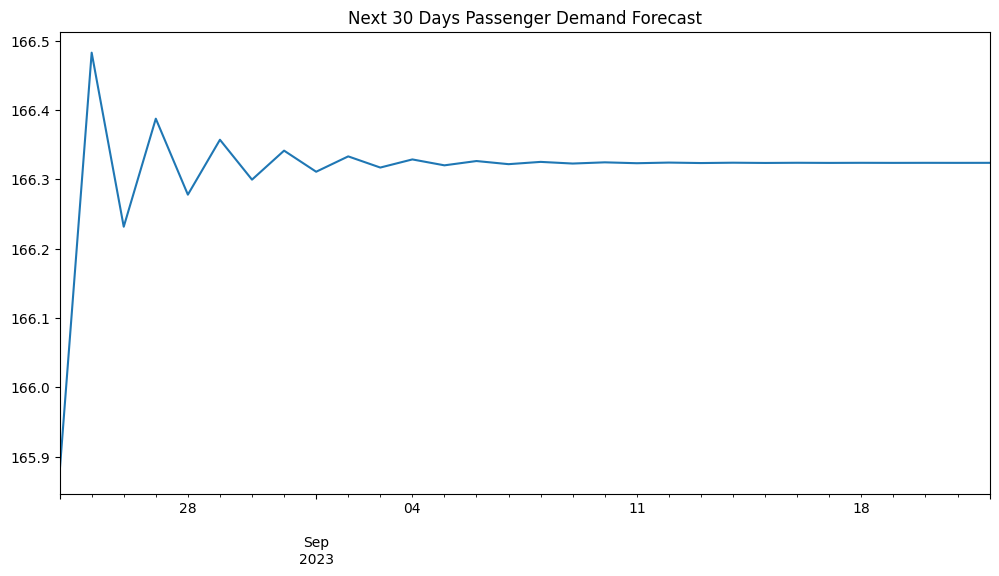

In [17]:
future_forecast = model_fit.forecast(steps=30)

future_forecast.plot(figsize=(12,6))

plt.title("Next 30 Days Passenger Demand Forecast")
plt.show()

Final Project Pipeline
Data Collection
       ↓
Time Series Visualization
       ↓
Decomposition
(Additive & Multiplicative)
       ↓
Detrend
       ↓
Deseasonalize
       ↓
ACF / PACF Analysis
       ↓
Stationarity Check
       ↓
ARIMA Model
       ↓
Passenger Demand Forecast
       ↓
Airline Revenue Optimization